# Capstone Porject Spotify

importing libraries and fixing random seeds

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# 1. Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

loading the dataset

In [2]:
# 2. Load and preprocess data
df = pd.read_csv("musicData.csv", na_values=['?', '-1.0', -1.0])
print(f"Original shape: {df.shape}")

Original shape: (50005, 18)


doing some transformation

In [3]:
# Drop rows with missing genre values
df = df.dropna(subset=['music_genre'])

# Feature categorization
categorical_features = ['key', 'mode']
non_feature_columns = ['instance_id', 'artist_name', 'track_name', 'obtained_date']
numerical_features = [col for col in df.columns if col not in 
                     categorical_features + non_feature_columns + ['music_genre']]

# 3. Create feature pipelines
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# 4. Encode target variable
label_encoder = LabelEncoder()
df['music_genre_encoded'] = label_encoder.fit_transform(df['music_genre'])
print(f"\nGenre mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")


Genre mapping: {'Alternative': 0, 'Anime': 1, 'Blues': 2, 'Classical': 3, 'Country': 4, 'Electronic': 5, 'Hip-Hop': 6, 'Jazz': 7, 'Rap': 8, 'Rock': 9}


train test split

In [4]:
# 5. Train/test split with 500 samples per genre in test set
test_indices = []
train_indices = []

for genre in np.unique(df['music_genre_encoded']):
    genre_mask = df['music_genre_encoded'] == genre
    genre_indices = df[genre_mask].index
    
    if len(genre_indices) < 500:
        print(f"⚠️ Warning: Genre {label_encoder.inverse_transform([genre])[0]} has only {len(genre_indices)} samples.")
        continue
    
    genre_sample = np.random.choice(genre_indices, size=500, replace=False)
    test_indices.extend(genre_sample)
    train_indices.extend([i for i in genre_indices if i not in genre_sample])

print(f"\nTrain set size: {len(train_indices)}")
print(f"Test set size: {len(test_indices)}")



Train set size: 45000
Test set size: 5000


since some of the features are available for engneering for better use, i have coded some basics for additional enhancements 

In [5]:
# 6. Feature engineering functions
def engineer_music_features(X):
    """Add music-specific engineered features"""
    X_eng = X.copy()
    
    # Energy-related features
    X_eng['energy_loudness_ratio'] = X_eng['energy'] / (np.abs(X_eng['loudness']) + 1)
    
    # Rhythm-related features
    X_eng['rhythm_strength'] = X_eng['danceability'] * X_eng['energy']
    
    # Complexity indicators
    X_eng['acoustic_instrumental_ratio'] = X_eng['acousticness'] / (X_eng['instrumentalness'] + 0.001)
    X_eng['speech_instrumental_balance'] = X_eng['speechiness'] / (X_eng['instrumentalness'] + 0.001)
    
    # Duration-based features
    X_eng['duration_minutes'] = X_eng['duration_ms'] / 60000
    
    # Emotional features
    X_eng['emotional_intensity'] = X_eng['energy'] * (1 - X_eng['valence'])
    X_eng['positivity'] = X_eng['valence'] * X_eng['danceability']
    
    # Tempo normalized
    X_eng['tempo_normalized'] = X_eng['tempo'] / 180.0
    
    return X_eng


In [6]:
def enhance_music_features(X):
    """Add genre-specific targeted features"""
    X_new = X.copy()
    
    # Features for difficult-to-distinguish genres
    
    # Hip-Hop vs Rap (biggest confusion)
    X_new['rap_vocal_focus'] = X_new['speechiness'] / (X_new['instrumentalness'] + 0.001)
    X_new['hiphop_beat_focus'] = X_new['energy'] * X_new['danceability'] * (1 - X_new['speechiness'])
    
    # Alternative vs Rock
    X_new['rock_intensity'] = X_new['energy'] * np.abs(X_new['loudness']) / 15
    X_new['alternative_mellowness'] = (1 - X_new['energy']) * X_new['acousticness']
    
    # Jazz vs Blues and Electronic
    X_new['jazz_complexity'] = X_new['instrumentalness'] * (1 - X_new['danceability'])
    X_new['blues_feeling'] = X_new['acousticness'] * (1 - X_new['valence'])
    
    # Country vs Rock/Alternative
    X_new['country_signature'] = X_new['acousticness'] * X_new['valence'] * (1 - X_new['energy'])

    # Alternative vs Rock - more detailed distinctions
    X_new['alt_rock_loudness_ratio'] = X_new['loudness'] / X_new['energy']
    X_new['alt_vocal_presence'] = X_new['speechiness'] * (1 - X_new['instrumentalness'])
    X_new['alt_mood_signature'] = X_new['valence'] * X_new['acousticness'] * (1 - X_new['energy'])
    
    # Alternative vs Country distinction
    X_new['alt_country_separator'] = X_new['acousticness'] * (1 - X_new['valence'])

    # Rap tends to be more vocal-focused
    X_new['rap_vocal_intensity'] = X_new['speechiness'] ** 2
    
    # Hip-Hop often has stronger beat/instrumental focus
    X_new['hiphop_beat_signature'] = X_new['danceability'] * X_new['energy'] * (1 - X_new['speechiness'])
    
    # Tempo variations
    X_new['rap_flow_tempo'] = X_new['tempo_normalized'] * X_new['speechiness']
    
    return X_new

In [7]:
# 7. Prepare features and targets
X = df.drop(['music_genre', 'music_genre_encoded'] + non_feature_columns, axis=1)
y = df['music_genre_encoded']

# Split data
X_train = X.loc[train_indices]
y_train = y.loc[train_indices]
X_test = X.loc[test_indices]
y_test = y.loc[test_indices]

In [8]:
# 8. Apply feature engineering
X_train_eng = engineer_music_features(X_train)
X_test_eng = engineer_music_features(X_test)

X_train_enhanced = enhance_music_features(X_train_eng)
X_test_enhanced = enhance_music_features(X_test_eng)


In [9]:
# 9. Create preprocessing pipeline
numerical_features_enhanced = [col for col in X_train_enhanced.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_enhanced),
        ('cat', categorical_transformer, categorical_features)
    ])

# 10. Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train_enhanced)
X_test_processed = preprocessor.transform(X_test_enhanced)
print(f"Processed features shape: {X_train_processed.shape}")

Processed features shape: (45000, 47)


In [10]:
# 11. Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)
print(f"PCA reduced features shape: {X_train_pca.shape}")

PCA reduced features shape: (45000, 15)


In [11]:
# 12. Binarize labels for ROC
n_classes = len(np.unique(y))
y_train_bin = label_binarize(y_train, classes=range(n_classes))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

In [12]:
# 13. Create and train binary classifiers for confused pairs
def train_binary_classifier(class1, class2):
    # Get indices for the two classes
    class1_idx = label_encoder.transform([class1])[0]
    class2_idx = label_encoder.transform([class2])[0]
    
    # Create masks for training and test data
    train_mask = np.isin(y_train, [class1_idx, class2_idx])
    test_mask = np.isin(y_test, [class1_idx, class2_idx])
    
    # Filter datasets to only include these classes
    X_train_binary = X_train_pca[train_mask]  # Use PCA features
    y_train_binary = y_train.iloc[train_mask]
    X_test_binary = X_test_pca[test_mask]
    y_test_binary = y_test.iloc[test_mask]
    
    # Convert to binary problem (0/1)
    y_train_binary = (y_train_binary == class2_idx).astype(int)
    y_test_binary = (y_test_binary == class2_idx).astype(int)
    
    # Train a specialized model
    binary_model = CalibratedClassifierCV(
        estimator=XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42
        ),
        method='isotonic',
        cv=3
    )
    
    binary_model.fit(X_train_binary, y_train_binary)
    
    # Evaluate
    y_pred_binary = binary_model.predict(X_test_binary)
    y_prob_binary = binary_model.predict_proba(X_test_binary)[:, 1]
    
    from sklearn.metrics import accuracy_score, roc_auc_score
    accuracy = accuracy_score(y_test_binary, y_pred_binary)
    auc_score = roc_auc_score(y_test_binary, y_prob_binary)
    
    print(f"{class1} vs {class2} Binary Classifier:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc_score:.4f}")
    
    return binary_model, (class1_idx, class2_idx)

In [13]:
# 14. Train main XGBoost model
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    random_state=42
)

# Optional: Use RandomizedSearchCV with a small n_iter for faster results
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc_ovr',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_pca, y_train)
best_model = search.best_estimator_
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best parameters: {'colsample_bytree': 0.9565643113363955, 'gamma': 0.04137769793552015, 'learning_rate': 0.08267769238729972, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 497, 'subsample': 0.6054203542535201}


In [14]:
# 15. Train binary classifiers for most confused pairs
binary_classifiers = {}
binary_classifiers['hip_rap'] = train_binary_classifier('Hip-Hop', 'Rap')
binary_classifiers['alt_rock'] = train_binary_classifier('Alternative', 'Rock')
binary_classifiers['jazz_blues'] = train_binary_classifier('Jazz', 'Blues')

Hip-Hop vs Rap Binary Classifier:
Accuracy: 0.5110
AUC: 0.5054
Alternative vs Rock Binary Classifier:
Accuracy: 0.7800
AUC: 0.8516
Jazz vs Blues Binary Classifier:
Accuracy: 0.8150
AUC: 0.9038


In [15]:
# 16. Hybrid ensemble prediction function
def hybrid_ensemble_predict(main_model, binary_models, X_test):
    # Get main model predictions
    main_probs = main_model.predict_proba(X_test)
    y_pred = main_model.predict(X_test)
    final_probs = main_probs.copy()
    
    # Adjust probabilities for frequently confused classes using binary classifiers
    for model_name, (model, (class1_idx, class2_idx)) in binary_models.items():
        # Find instances predicted as either of these classes
        mask = np.isin(y_pred, [class1_idx, class2_idx])
        
        if np.sum(mask) > 0:
            # Get binary classifier probabilities
            binary_probs = model.predict_proba(X_test[mask])
            
            # Adjust the probabilities for these specific classes
            for i, idx in enumerate(np.where(mask)[0]):
                p = binary_probs[i, 1]  # Probability of class2
                
                # Update the probabilities for these two classes only
                class_sum = main_probs[idx, class1_idx] + main_probs[idx, class2_idx]
                final_probs[idx, class1_idx] = class_sum * (1 - p)
                final_probs[idx, class2_idx] = class_sum * p
                
                # Renormalize
                final_probs[idx] = final_probs[idx] / np.sum(final_probs[idx])
    
    return final_probs


In [16]:
# 17. Get ensemble predictions
hybrid_probs = hybrid_ensemble_predict(best_model, binary_classifiers, X_test_pca)

# 18. Calculate AUC
hybrid_auc = roc_auc_score(y_test_bin, hybrid_probs, average='macro')
print(f"Hybrid ensemble AUC: {hybrid_auc:.4f}")

Hybrid ensemble AUC: 0.9225


----------

### Visualizations

ROC curve

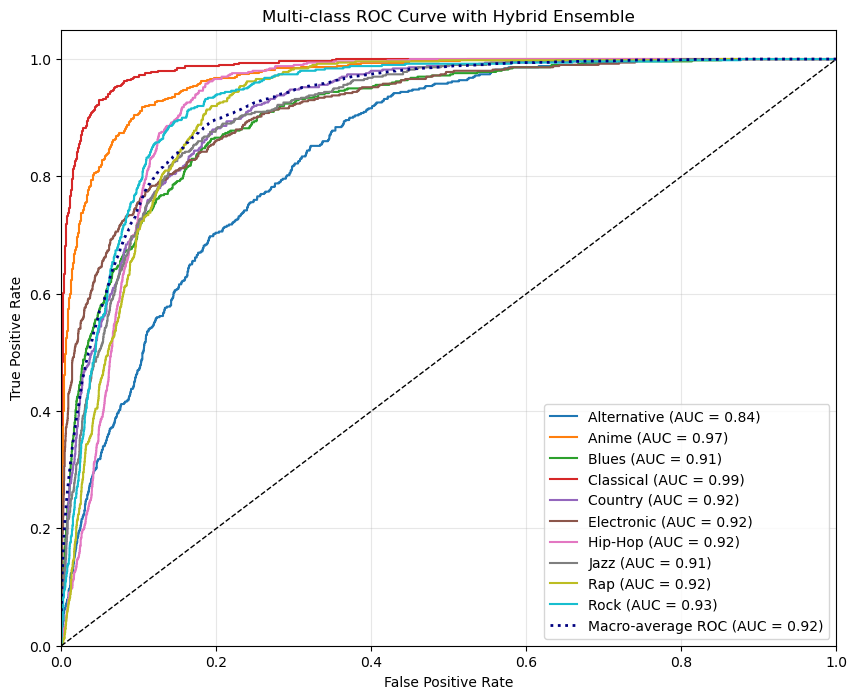

In [18]:
# 19. Plot ROC Curve
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

# Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], hybrid_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=1.5,
             label=f'{label_encoder.inverse_transform([i])[0]} (AUC = {roc_auc[i]:.2f})')

# Calculate macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

plt.plot(all_fpr, mean_tpr, color='navy', linestyle=':', linewidth=2,
         label=f'Macro-average ROC (AUC = {hybrid_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve with Hybrid Ensemble')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('hybrid_roc_curve.png')
plt.show()

confusion matrix

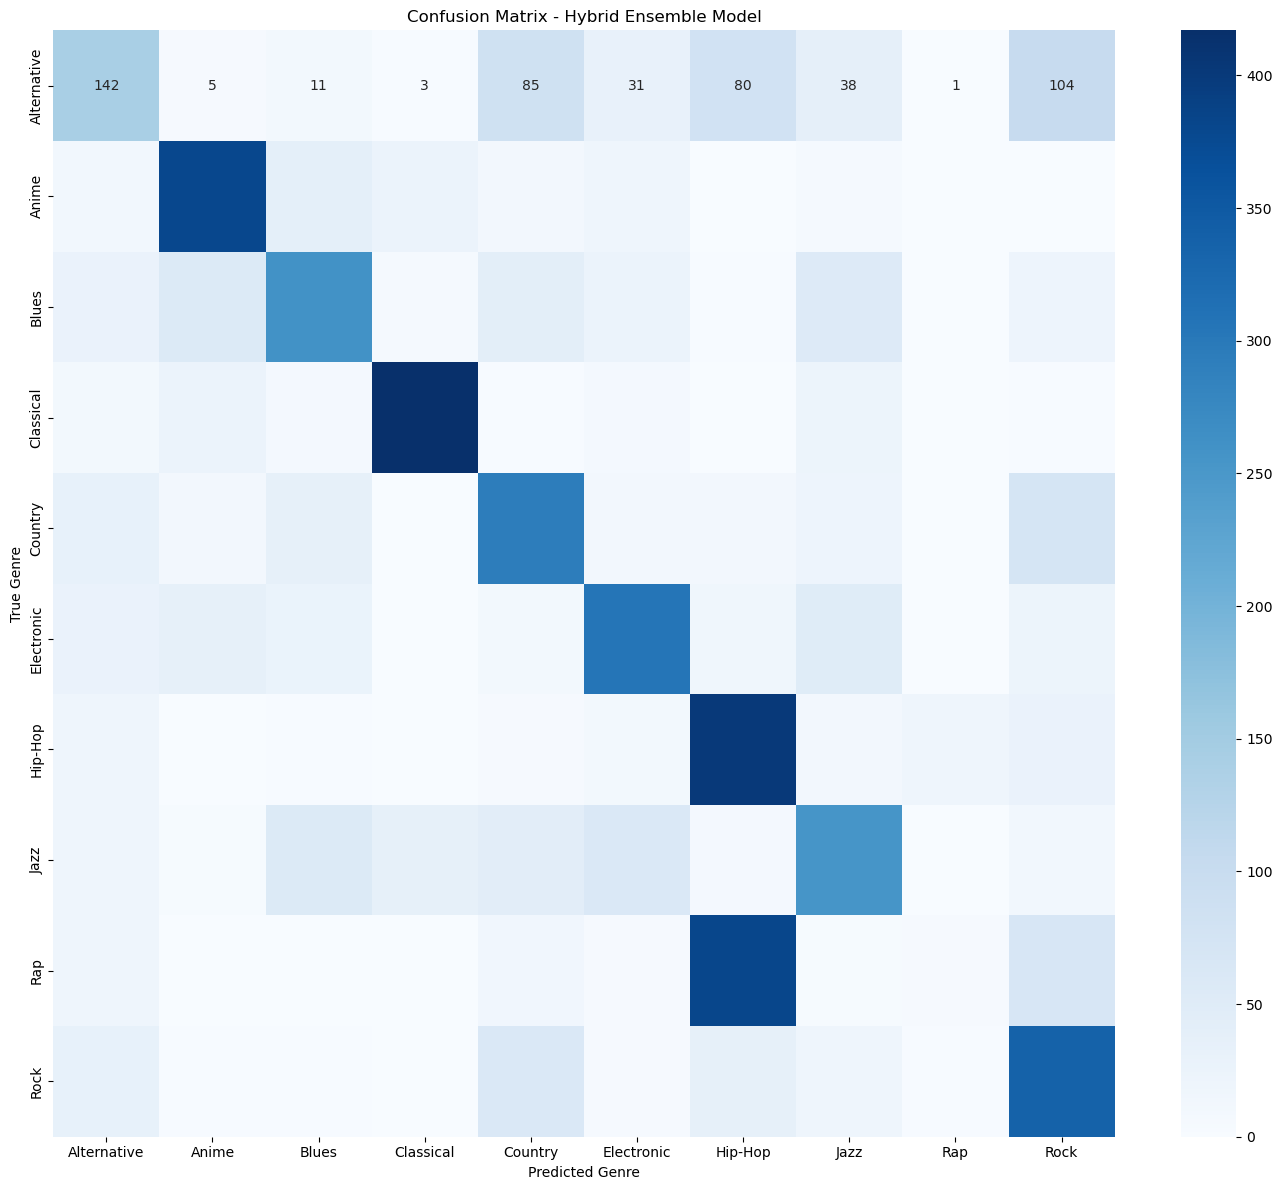

In [19]:
# Get predictions from hybrid model
y_pred_hybrid = np.argmax(hybrid_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_hybrid)

# Get genre names
genre_names = [label_encoder.inverse_transform([i])[0] for i in range(n_classes)]

# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_names,
            yticklabels=genre_names)
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.title('Confusion Matrix - Hybrid Ensemble Model')
plt.tight_layout()
plt.savefig('hybrid_confusion_matrix.png')
plt.show()

feature importance

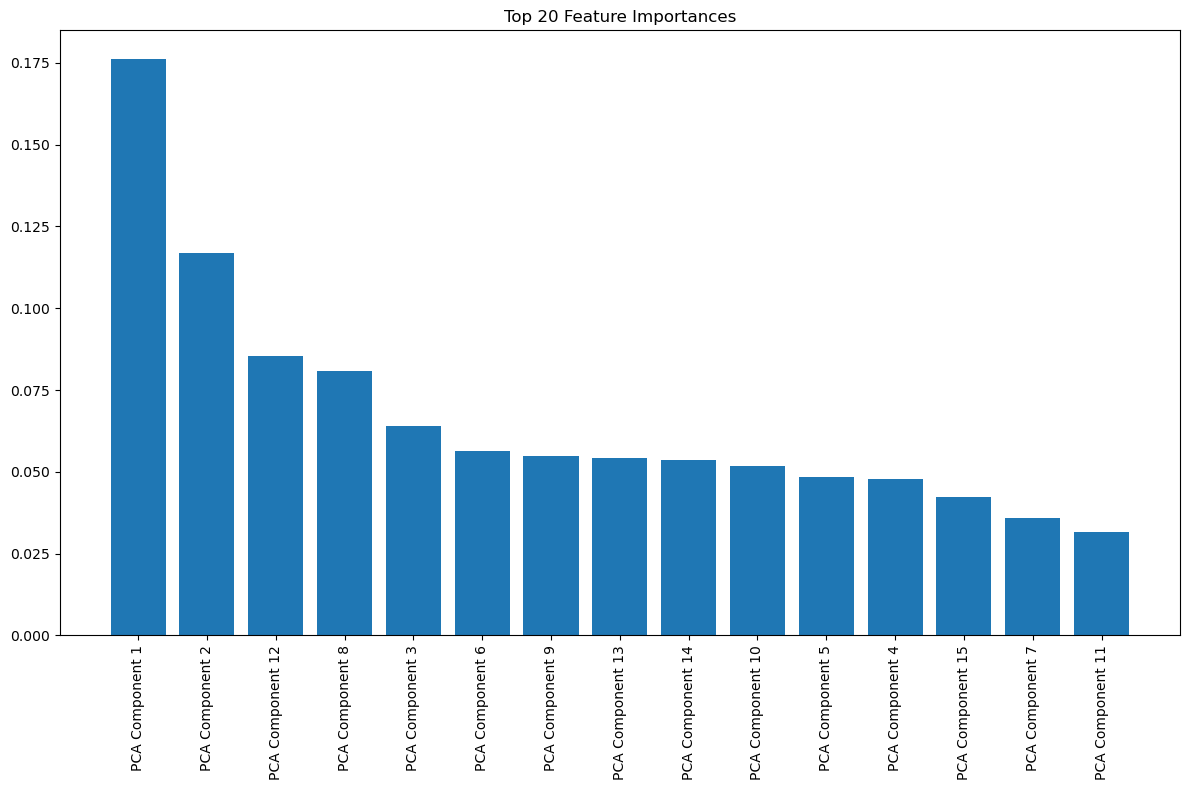

In [20]:
# Feature importance visualization (for XGBoost model)
if hasattr(best_model, 'feature_importances_'):
    # Get feature names from preprocessor
    feature_names = []
    for name, transformer, columns in preprocessor.transformers_:
        if name == 'cat':
            # Get one-hot encoded feature names
            feature_names.extend(transformer.named_steps['onehot'].get_feature_names_out(columns))
        else:
            # Get numerical feature names
            feature_names.extend(columns)
    
    # If we have more features than importances (due to PCA), limit to PCA features
    if len(feature_names) > len(best_model.feature_importances_):
        feature_names = [f'PCA Component {i+1}' for i in range(len(best_model.feature_importances_))]
    
    # Sort features by importance
    indices = np.argsort(best_model.feature_importances_)[::-1]
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    plt.title('Top 20 Feature Importances')
    plt.bar(range(min(20, len(indices))), 
            best_model.feature_importances_[indices][:20],
            align='center')
    plt.xticks(range(min(20, len(indices))), 
              [feature_names[i] if i < len(feature_names) else f'Feature {i}' 
               for i in indices[:20]], 
              rotation=90)
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

genre AUC scores

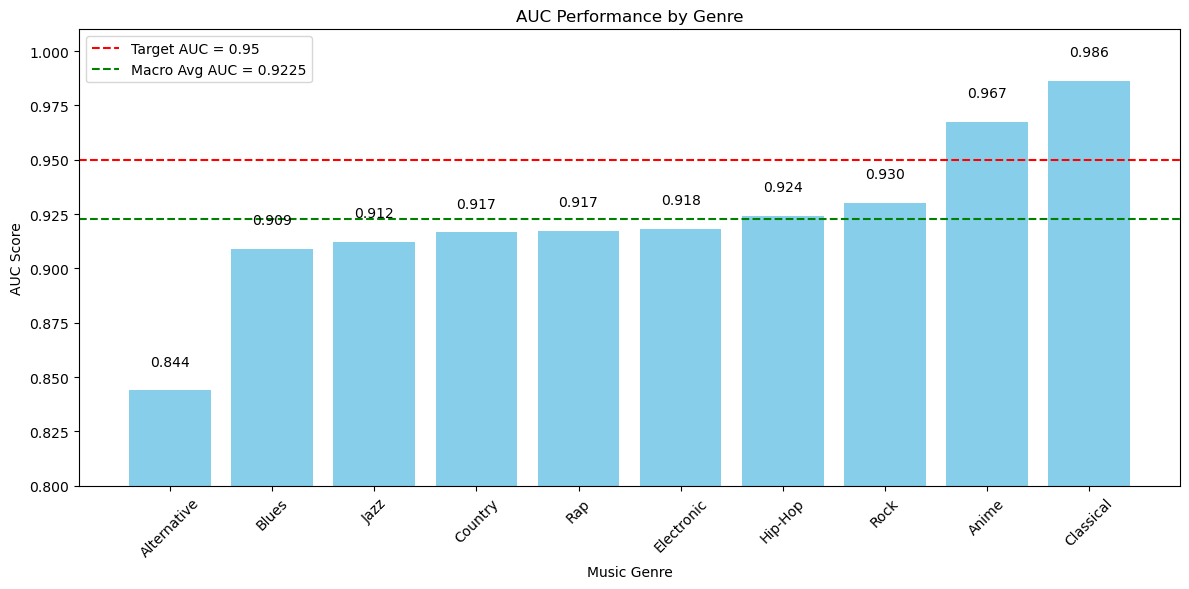

In [21]:
# Plot per-class AUC scores
plt.figure(figsize=(12, 6))
auc_scores = [roc_auc[i] for i in range(n_classes)]
genre_auc = list(zip(genre_names, auc_scores))
genre_auc.sort(key=lambda x: x[1])  # Sort by AUC score

genres, scores = zip(*genre_auc)
bars = plt.bar(genres, scores, color='skyblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='Target AUC = 0.95')
plt.axhline(y=hybrid_auc, color='green', linestyle='--', label=f'Macro Avg AUC = {hybrid_auc:.4f}')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', rotation=0)

plt.ylim(0.80, 1.01)  # Set y-axis limits for better visualization
plt.xlabel('Music Genre')
plt.ylabel('AUC Score')
plt.title('AUC Performance by Genre')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('genre_auc_scores.png')
plt.show()

t-SNE

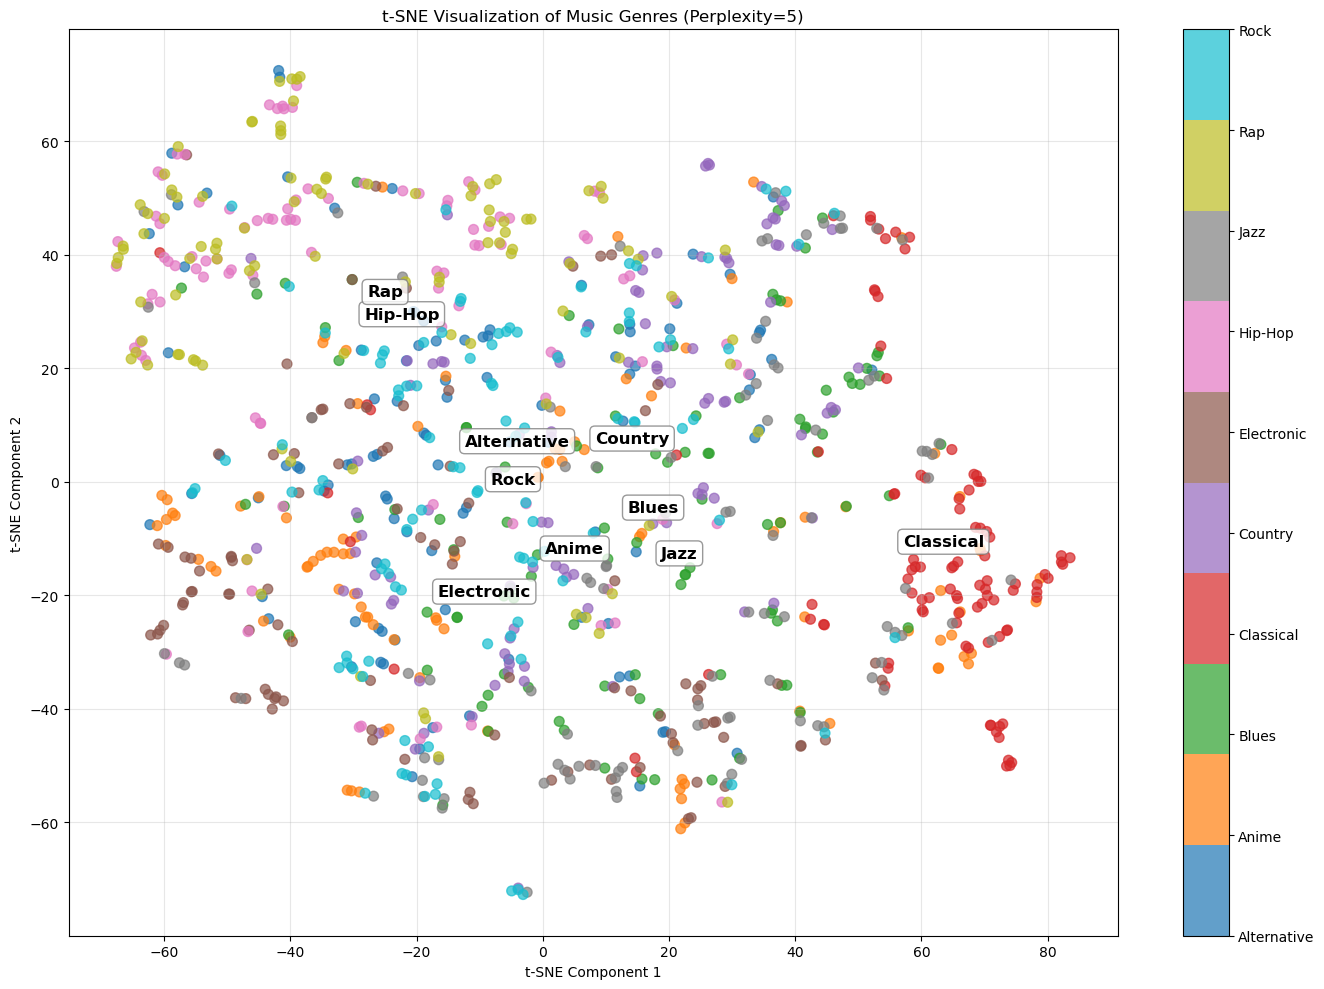

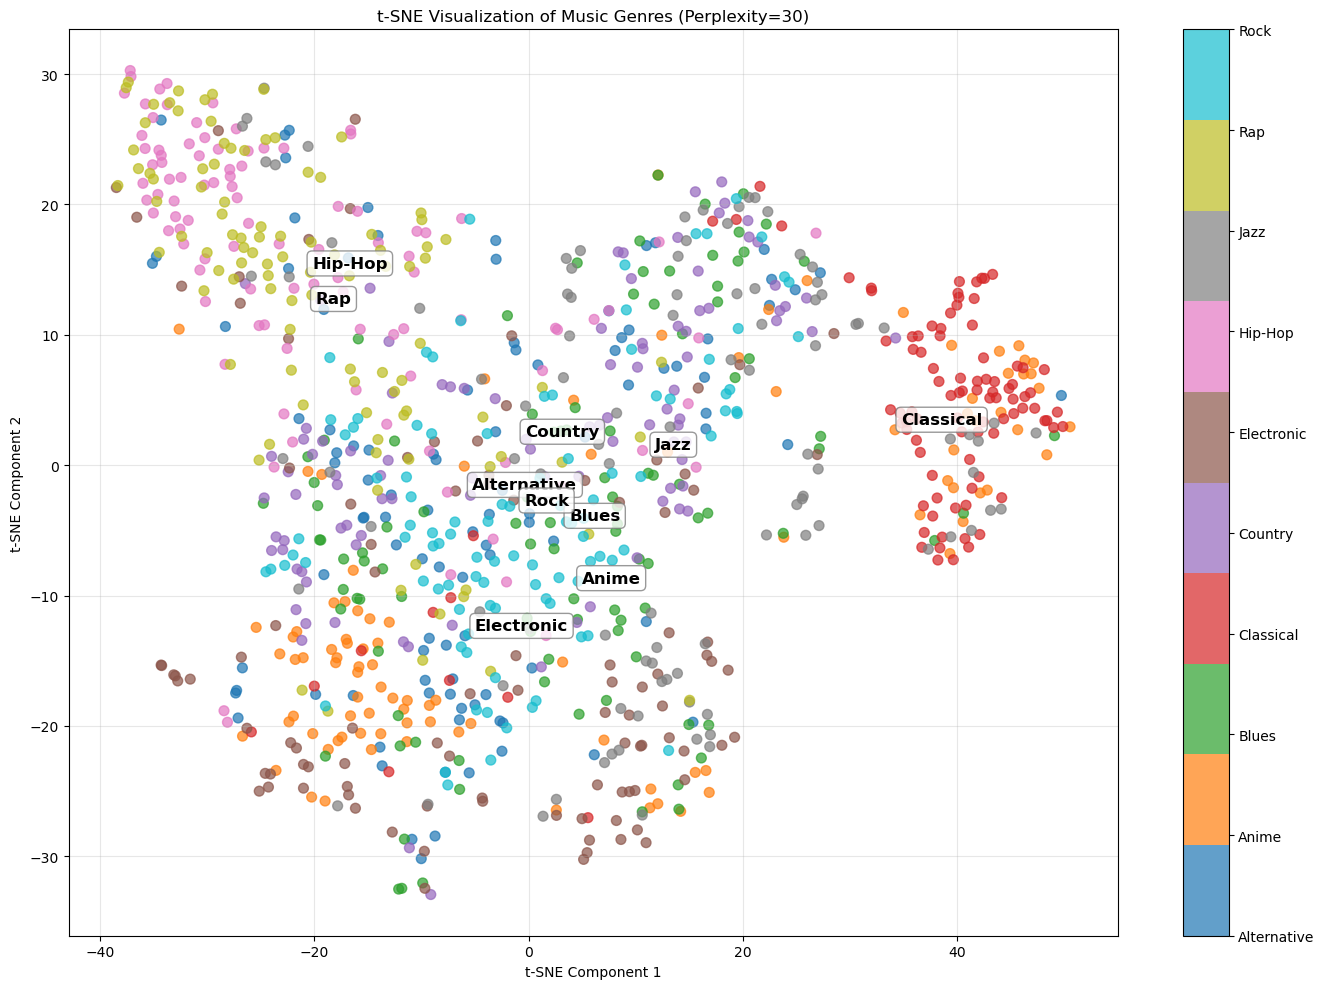

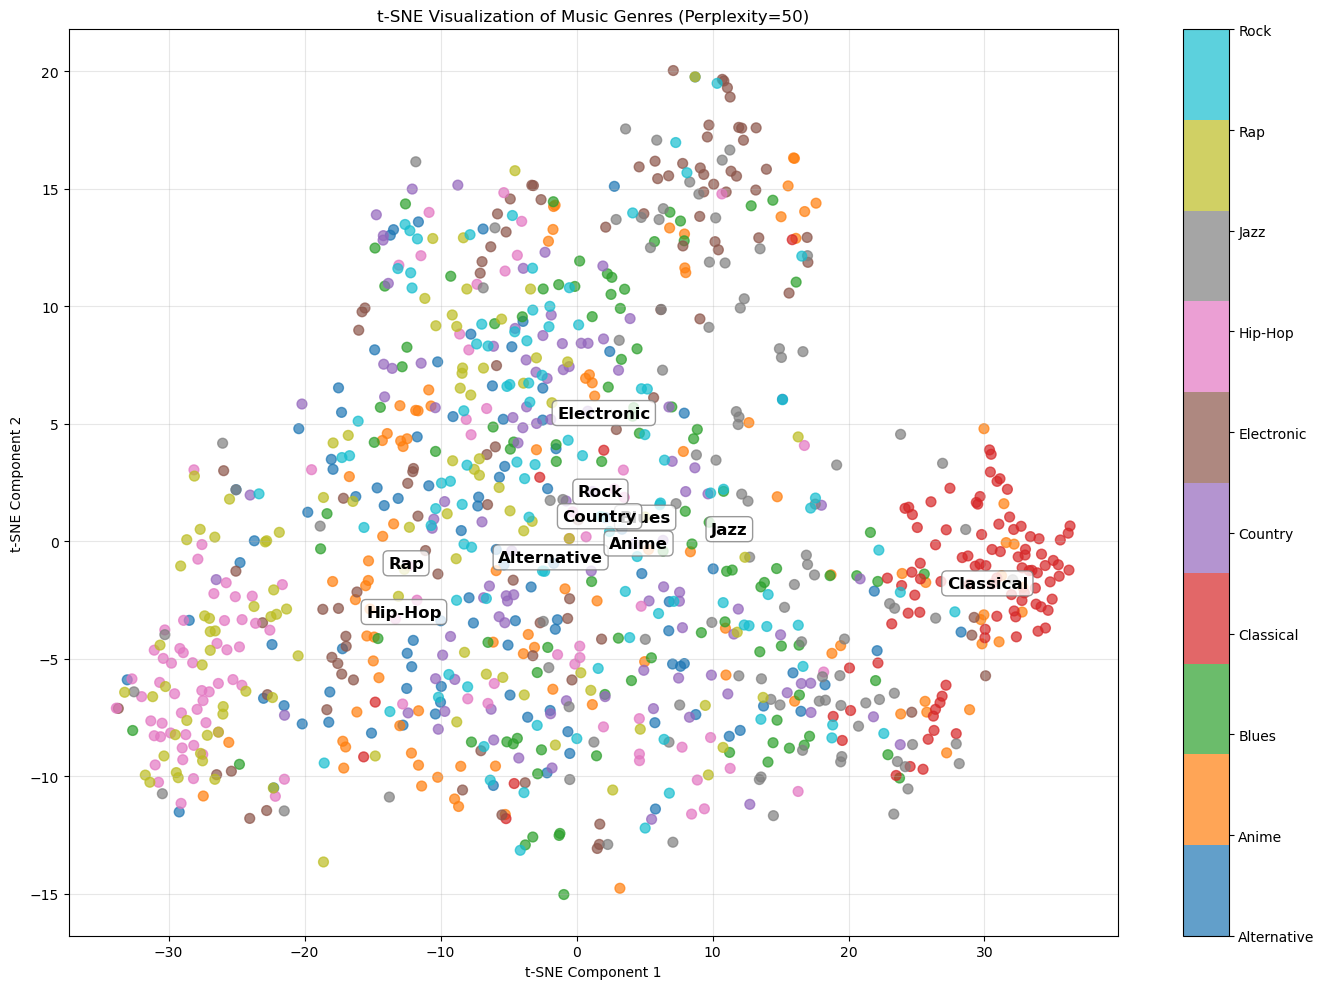

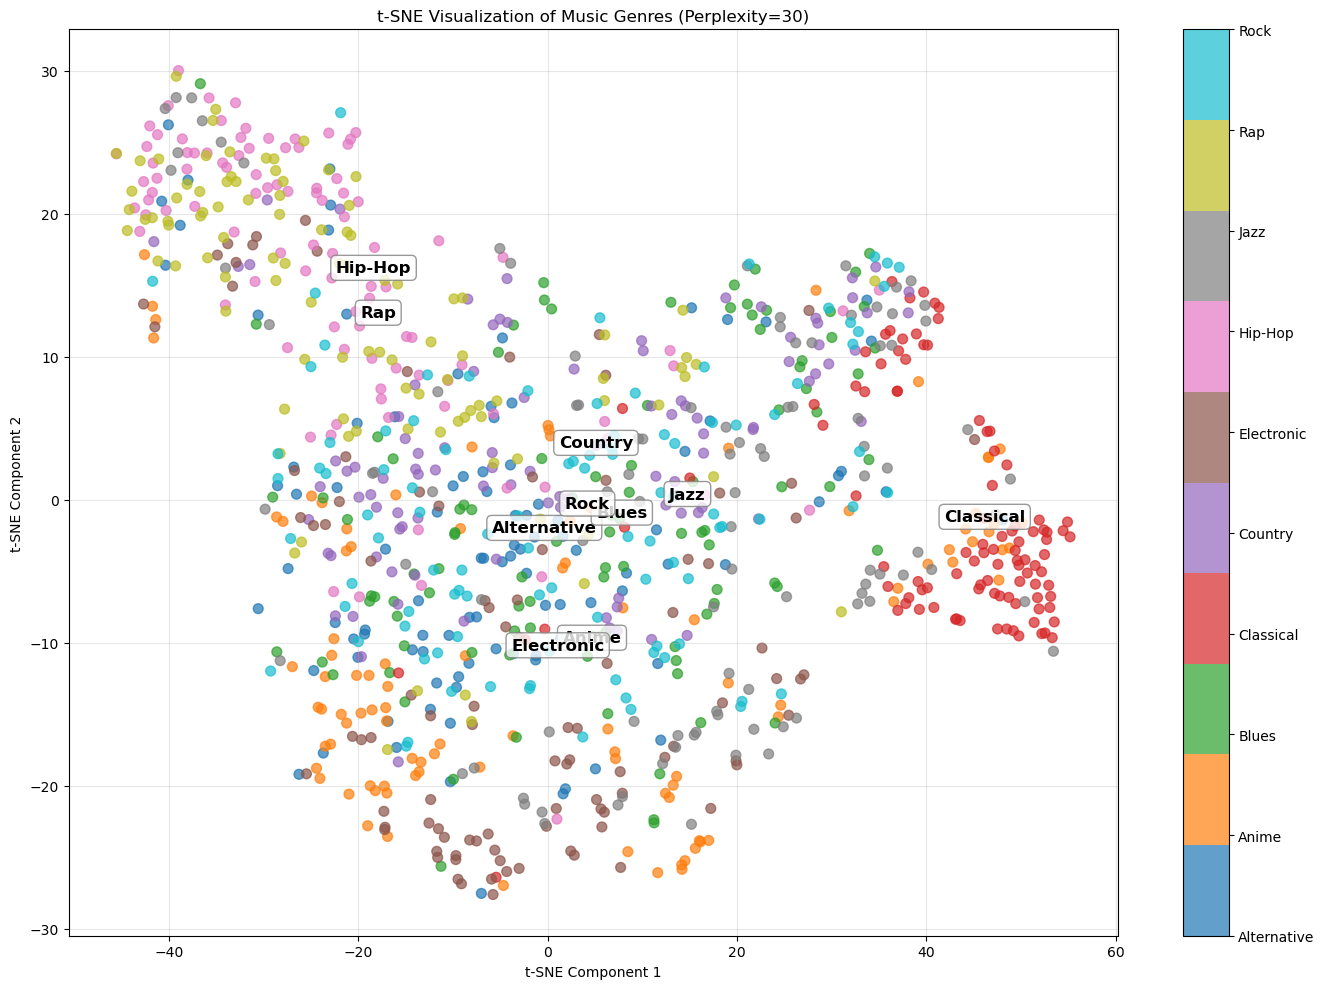

In [22]:
# Create t-SNE visualization
def plot_tsne(X, y, perplexity=30, n_components=2):
    # Get a subset of the data to make t-SNE computation feasible
    # Ensure we get a balanced sample across genres
    n_per_class = 100  # samples per genre
    sample_indices = []
    
    for genre_idx in range(n_classes):
        genre_indices = np.where(y == genre_idx)[0]
        if len(genre_indices) > n_per_class:
            sampled = np.random.choice(genre_indices, n_per_class, replace=False)
        else:
            sampled = genre_indices
        sample_indices.extend(sampled)
    
    X_sample = X[sample_indices]
    y_sample = y[sample_indices]
    
    # Apply t-SNE
    tsne = TSNE(n_components=n_components, 
                perplexity=perplexity, 
                random_state=42,
                init='pca',  # Using PCA for initialization helps with stability
                learning_rate='auto')
    X_tsne = tsne.fit_transform(X_sample)
    
    # Plot the results
    plt.figure(figsize=(14, 10))
    
    # Create scatter plot with genre colors
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                         c=y_sample, cmap='tab10', 
                         alpha=0.7, s=50)
    
    # Add colorbar legend
    genre_names = [label_encoder.inverse_transform([i])[0] for i in range(n_classes)]
    cbar = plt.colorbar(scatter, ticks=range(n_classes))
    cbar.set_ticklabels(genre_names)
    
    # Add genre labels at centroids
    for genre_idx in range(n_classes):
        mask = y_sample == genre_idx
        if np.sum(mask) > 0:
            centroid_x = np.mean(X_tsne[mask, 0])
            centroid_y = np.mean(X_tsne[mask, 1])
            plt.annotate(genre_names[genre_idx], 
                        (centroid_x, centroid_y),
                        fontsize=12, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    plt.title(f't-SNE Visualization of Music Genres (Perplexity={perplexity})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'tsne_visualization_p{perplexity}.png')
    plt.show()
    
    return X_tsne, y_sample

# Create multiple t-SNE plots with different perplexity values
# Perplexity affects how t-SNE balances attention between local and global aspects
perplexities = [5, 30, 50]
for perp in perplexities:
    X_tsne, y_sample = plot_tsne(X_train_processed, y_train.values, perplexity=perp)

# Create t-SNE on the PCA-reduced data (often works better)
X_tsne_pca, y_sample_pca = plot_tsne(X_train_pca, y_train.values, perplexity=30)

---------------------

### Extra Credits

here I generate 2 additional graphs

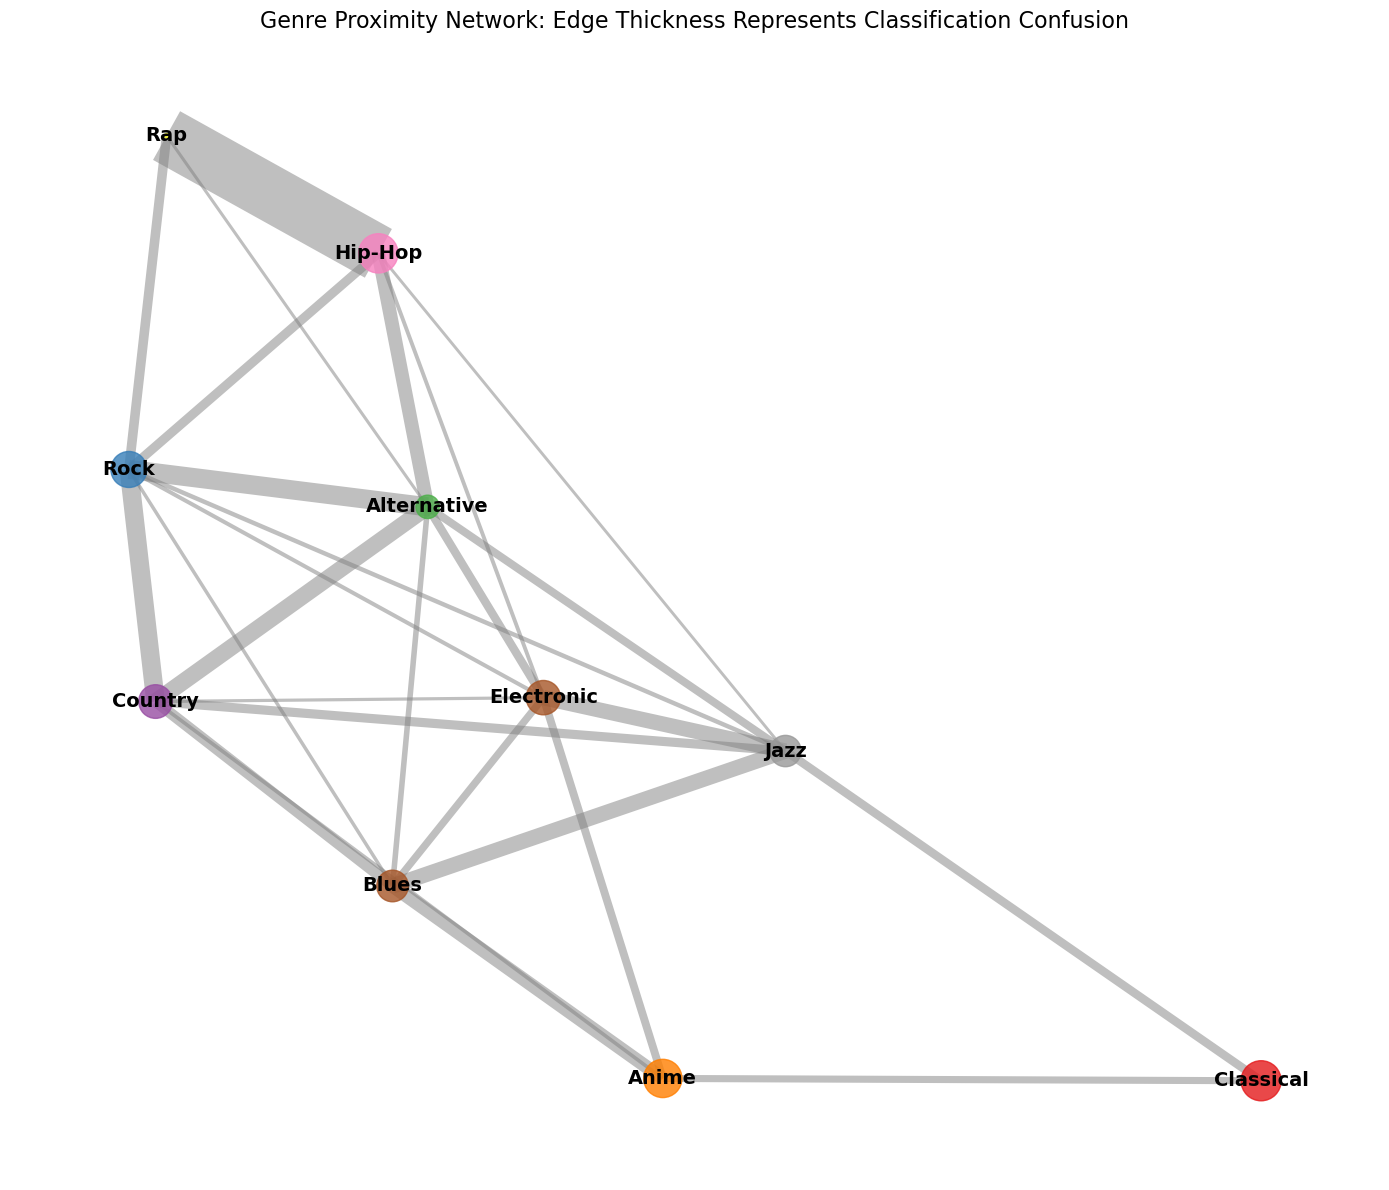

Top 5 most confused genre pairs:
1. Hip-Hop ↔ Rap: 401 instances
2. Alternative ↔ Rock: 138 instances
3. Country ↔ Rock: 134 instances
4. Alternative ↔ Country: 119 instances
5. Blues ↔ Jazz: 111 instances


In [23]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create a genre proximity network based on confusion matrix
def create_genre_network(confusion_matrix, genre_names, min_edge_weight=10):
    # Create a graph
    G = nx.Graph()
    
    # Add nodes (genres)
    for i, genre in enumerate(genre_names):
        # Size nodes by classification accuracy (diagonal of confusion matrix)
        accuracy = confusion_matrix[i, i] / np.sum(confusion_matrix[i, :])
        G.add_node(genre, size=accuracy * 1000)  # Scale for visibility
    
    # Add edges (confusion between genres)
    for i in range(len(genre_names)):
        for j in range(i+1, len(genre_names)):
            # Edge weight is sum of confusions in both directions
            weight = confusion_matrix[i, j] + confusion_matrix[j, i]
            if weight >= min_edge_weight:  # Only add significant connections
                G.add_edge(genre_names[i], genre_names[j], weight=weight)
    
    return G

# Extract data from confusion matrix
cm_array = cm  # Your existing confusion matrix
genres = [label_encoder.inverse_transform([i])[0] for i in range(n_classes)]

# Create network
G = create_genre_network(cm_array, genres, min_edge_weight=20)

# Create custom colormap for nodes based on genre categories
genre_colors = {
    'Classical': '#e41a1c',
    'Anime': '#ff7f00',
    'Rock': '#377eb8',
    'Alternative': '#4daf4a',
    'Country': '#984ea3',
    'Blues': '#a65628',
    'Jazz': '#999999',
    'Electronic': '#a65628',
    'Hip-Hop': '#f781bf',
    'Rap': '#ffff33'
}

# Prepare the visualization
plt.figure(figsize=(14, 12))

# Calculate node positions using force-directed layout
pos = nx.spring_layout(G, k=0.4, seed=42)

# Draw nodes
node_sizes = [G.nodes[node]['size'] for node in G.nodes()]
node_colors = [genre_colors[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

# Draw edges with weights affecting thickness
edge_weights = [G[u][v]['weight']/10 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.5, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

plt.title('Genre Proximity Network: Edge Thickness Represents Classification Confusion', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('genre_network.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and print the most confused genre pairs
edges = [(u, v, G[u][v]['weight']) for u, v in G.edges()]
edges.sort(key=lambda x: x[2], reverse=True)
print("Top 5 most confused genre pairs:")
for i, (genre1, genre2, weight) in enumerate(edges[:5]):
    print(f"{i+1}. {genre1} ↔ {genre2}: {weight:.0f} instances")

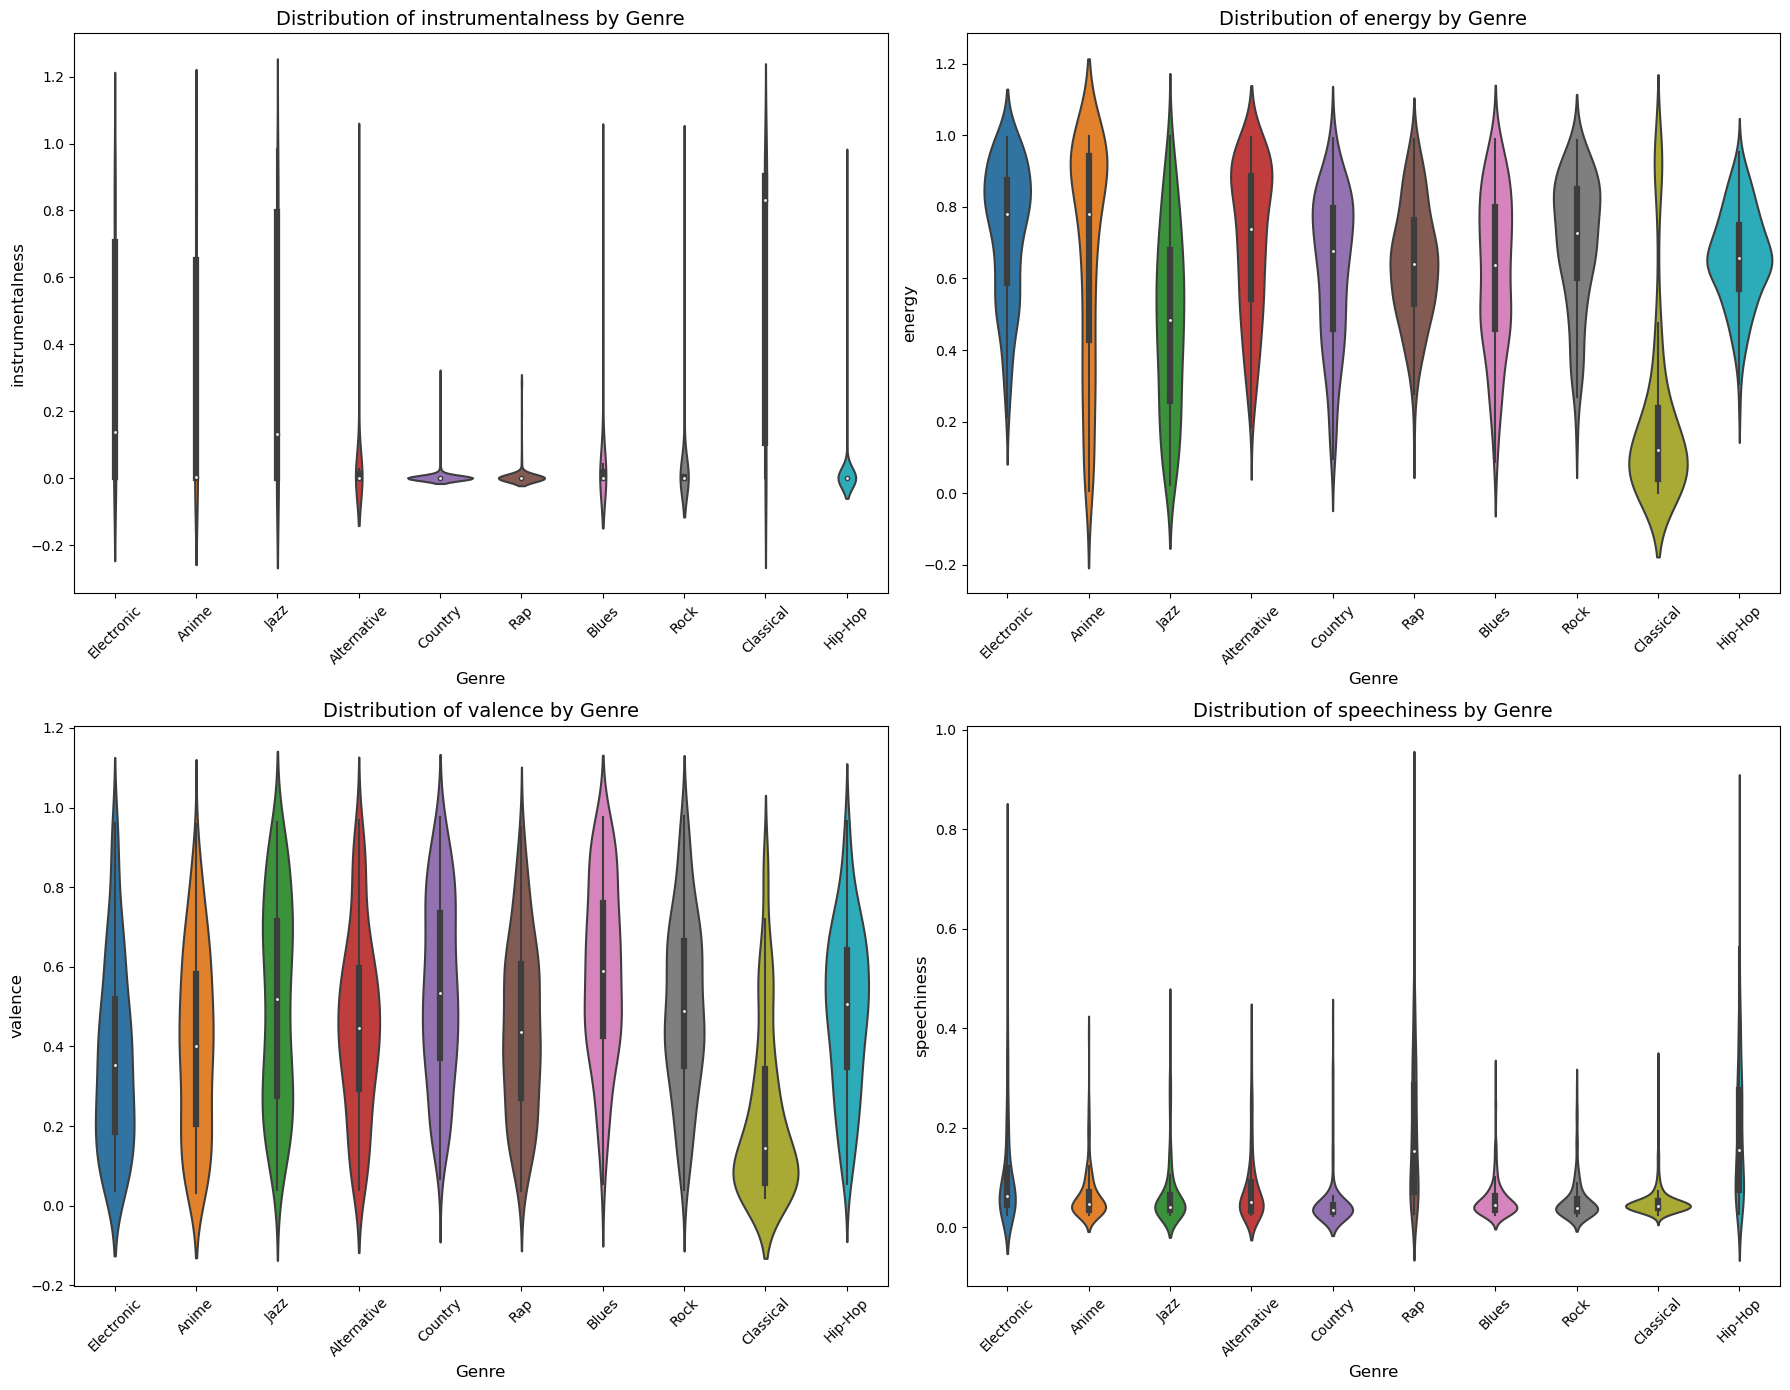

Interesting insights from feature distributions:
Electronic: Most distinctive feature is 'instrumentalness' (mean: 0.348, 91.7% different from overall)
Anime: Most distinctive feature is 'instrumentalness' (mean: 0.278, 53.1% different from overall)
Jazz: Most distinctive feature is 'instrumentalness' (mean: 0.354, 95.1% different from overall)
Alternative: Most distinctive feature is 'instrumentalness' (mean: 0.061, 66.5% different from overall)
Country: Most distinctive feature is 'instrumentalness' (mean: 0.005, 97.1% different from overall)
Rap: Most distinctive feature is 'speechiness' (mean: 0.187, 99.5% different from overall)
Blues: Most distinctive feature is 'instrumentalness' (mean: 0.094, 48.2% different from overall)
Rock: Most distinctive feature is 'instrumentalness' (mean: 0.055, 69.9% different from overall)
Classical: Most distinctive feature is 'instrumentalness' (mean: 0.601, 230.8% different from overall)
Hip-Hop: Most distinctive feature is 'speechiness' (mean: 0.

In [24]:
import seaborn as sns

# Create a function to plot feature distributions by genre
def plot_feature_distributions(df, features, genre_col='music_genre'):
    # Sample data to avoid overcrowding (take 200 samples per genre)
    samples = []
    for genre in df[genre_col].unique():
        genre_data = df[df[genre_col] == genre].sample(min(200, df[df[genre_col] == genre].shape[0]))
        samples.append(genre_data)
    
    sampled_df = pd.concat(samples)
    
    # Create a grid of violin plots
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        ax = axes[i]
        sns.violinplot(x=genre_col, y=feature, data=sampled_df, palette='tab10', ax=ax)
        ax.set_title(f'Distribution of {feature} by Genre', fontsize=14)
        ax.set_xlabel('Genre', fontsize=12)
        ax.set_ylabel(feature, fontsize=12)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Select the most interesting features
key_features = ['instrumentalness', 'energy', 'valence', 'speechiness']

# Create a DataFrame with original features and genre
# Note: You'll need to adjust this to match your data structure
feature_df = df[key_features + ['music_genre']].copy()

# Plot the distributions
plot_feature_distributions(feature_df, key_features)

# Calculate and print interesting insights about the distributions
print("Interesting insights from feature distributions:")
for genre in df['music_genre'].unique():
    genre_data = df[df['music_genre'] == genre]
    
    # Find the most distinctive feature for this genre
    feature_means = {}
    for feature in key_features:
        genre_mean = genre_data[feature].mean()
        overall_mean = df[feature].mean()
        difference = abs(genre_mean - overall_mean) / overall_mean  # Relative difference
        feature_means[feature] = (genre_mean, difference)
    
    # Get most distinctive feature
    most_distinctive = max(feature_means.items(), key=lambda x: x[1][1])
    
    print(f"{genre}: Most distinctive feature is '{most_distinctive[0]}' " 
          f"(mean: {most_distinctive[1][0]:.3f}, {most_distinctive[1][1]*100:.1f}% different from overall)")